In [7]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [8]:
class BatsmanState(TypedDict):
    runs: int
    balls: int
    fours: int
    sixes: int

    sr: float
    bpb: float
    boundary_percentage: float
    summary: str

In [9]:
def Calculate_sr(state:BatsmanState)->BatsmanState:
    sr = (state['runs'] / state['balls']) * 100
    
    return {'sr': sr}

def Calculate_bpb(state:BatsmanState)->BatsmanState:
     total_boundaries = state['fours'] + state['sixes']
     bpb = state['balls'] / total_boundaries
 
     return {'bpb': bpb}

def Calculate_boundary_percent(state:BatsmanState)->BatsmanState:
    boundary_percentage = (
        ((state['fours'] * 4) + (state['sixes'] * 6))
        / state['runs']
    ) * 100

    return {'boundary_percentage': boundary_percentage}

def Summary(state:BatsmanState):

    summary = f"""
  Strike Rate: {state['sr']:.2f}
  Balls per Boundary: {state['bpb']:.2f}
  Boundary Percentage: {state['boundary_percentage']:.2f}

    """
        
    return {'summary': summary}

In [10]:
graph = StateGraph(BatsmanState)

# nodes
graph.add_node('calculate_sr',Calculate_sr)
graph.add_node('calculate_bpb',Calculate_bpb)
graph.add_node('calculate_boundary_percent',Calculate_boundary_percent)
graph.add_node('summary',Summary)

# edges
graph.add_edge(START,'calculate_sr')
graph.add_edge(START,'calculate_bpb')   
graph.add_edge(START,'calculate_boundary_percent')

graph.add_edge('calculate_sr','summary')
graph.add_edge('calculate_bpb','summary')
graph.add_edge('calculate_boundary_percent','summary')

graph.add_edge('summary',END)

# compile the graph
workflow = graph.compile()


In [14]:
input_state = {
    "runs": 100,
    "balls": 50,
    "fours": 6,
    "sixes": 4
}

result = workflow.invoke(input_state)
print(result)

{'runs': 100, 'balls': 50, 'fours': 6, 'sixes': 4, 'sr': 200.0, 'bpb': 5.0, 'boundary_percentage': 48.0, 'summary': '\n  Strike Rate: 200.00\n  Balls per Boundary: 5.00\n  Boundary Percentage: 48.00\n\n    '}


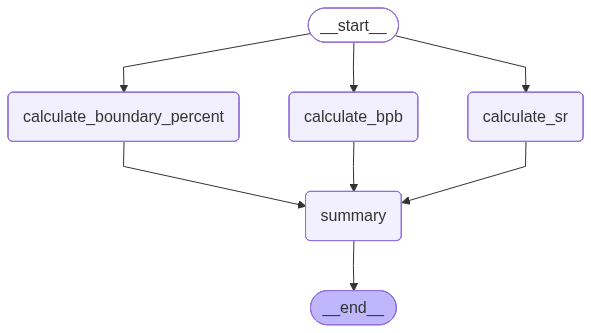

In [15]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())